# Reward samples from physical robot interactions
See: https://www.tokic.com/the-crawling-robot/
![title](https://github.com/micheltokic/crawlingrobot/blob/master/hardware-robot-reward-model.png?raw=true)

In [61]:
import numpy as np
import matplotlib.pyplot as plt
#!python -m pip install mdptoolbox-hiive
#!python -m pip list
#!which python

# Actions refer to columns in RewardModel 
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3
ACTIONS =          np.array([ UP,   RIGHT,   DOWN,   LEFT], dtype=int)
ACTIONS_READABLE =          ["UP", "RIGHT", "DOWN", "LEFT"]

In [13]:
###################################
## Definition of reward model
### (no need to do anything here!)
###################################

# grid size
ROWS = 5
COLS = 5

RewardModel = np.zeros((COLS, ROWS, len(ACTIONS)))

#RewardModel[row][column][action]

# 1. row (ACTIONS: UP, RIGHT, DOWN, LEFT)
RewardModel[0][0] = [  0,  0,  0,   0]
RewardModel[0][1] = [  0,  0,  0,   0]
RewardModel[0][2] = [  0,  0,  0,   0]
RewardModel[0][3] = [  0,  0,  0,   0]
RewardModel[0][4] = [  0,  0,  0,   0]
# 2.row
RewardModel[1][0] = [  0,  0,  0,   0]
RewardModel[1][1] = [  0,  0,  0,   0]
RewardModel[1][2] = [  0,  0,  0,   0]
RewardModel[1][3] = [  0,  0,  4,   0]
RewardModel[1][4] = [  0,  0,  6,   0] # e.g. row 1, col 4 has reward of 6 for action 3 (DOWN)
#3. row
RewardModel[2][0] = [  0,  0,  9,   0]
RewardModel[2][1] = [  0,  0, 11,   0]
RewardModel[2][2] = [  0, 15,  0,   0]
RewardModel[2][3] = [ -3, 12, 17, -10]
RewardModel[2][4] = [ -4,  0, 16, -11]
#4. row
RewardModel[3][0] = [ -5, 17, 19,   0]
RewardModel[3][1] = [ -9, 17, 20,  -8]
RewardModel[3][2] = [-16, 13, 19, -12]
RewardModel[3][3] = [-18, 12, 23, -14]
RewardModel[3][4] = [-16,  0, 23, -18]
#5. row
RewardModel[4][0] = [ -8, 14,  0,   0]
RewardModel[4][1] = [-26, 16,  0,  -6]
RewardModel[4][2] = [-18,  9,  0, -14]
RewardModel[4][3] = [-26, 10,  0, -15]
RewardModel[4][4] = [-30,  0,  0, -15]

print (RewardModel)

[[[  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]]

 [[  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   4.   0.]
  [  0.   0.   6.   0.]]

 [[  0.   0.   9.   0.]
  [  0.   0.  11.   0.]
  [  0.  15.   0.   0.]
  [ -3.  12.  17. -10.]
  [ -4.   0.  16. -11.]]

 [[ -5.  17.  19.   0.]
  [ -9.  17.  20.  -8.]
  [-16.  13.  19. -12.]
  [-18.  12.  23. -14.]
  [-16.   0.  23. -18.]]

 [[ -8.  14.   0.   0.]
  [-26.  16.   0.  -6.]
  [-18.   9.   0. -14.]
  [-26.  10.   0. -15.]
  [-30.   0.   0. -15.]]]


In [14]:
####################################
# Implement ValueIteration function
####################################
def ValueIteration (R, maxIterations = 10000, theta = 0.000001, gamma=0.999):
    
    rows, cols = R.shape[0:2]
    
    V = np.zeros((rows, cols))
    pi = np.zeros((rows, cols), dtype=int)
    
    iteration = 0
    end = False
    while (not end):
        
        error = 0
        iteration += 1
        
        for x in range( 0, cols):
            for y in np.arange (0, rows):
        
                bestNewV = -np.inf
                
                for action in ACTIONS:
                    newX = x;
                    newY = y;
                    reward = R[y][x][action]

                    ## DONE: Recompute newX/newY according to action to be evaluated
                    ##       => Forbid actions across grid boundaries!
                    if action == DOWN:
                        if (y+1) >= rows:
                            continue
                        newY = y+1
                    if action == UP:
                        if y-1 < 0:
                            continue
                        newY = y - 1
                    if action == LEFT:
                        if x-1 < 0:
                            continue
                        newX = x -1
                    if action == RIGHT:
                        if x+1 >= cols:
                            continue
                        newX = x + 1
                    

                    ## DONE:  recompute value of current state (current reward + discounted reward)
                    newV = reward + gamma * V[newY][newX]
                    
                    ## DONE: memorize estimated best action and hightes V value in current state s
                    if newV > bestNewV:
                        bestNewV = newV
                        bestAction = action

                ## DONE: measure maximum value error in current iteration
                error = max (error, abs(V[y][x] - bestNewV))
                
                # update estimated state value and policy action
                V[y][x] = bestNewV
                pi[y][x] = bestAction
                
        ## DONE: check iteration termination
        if (iteration >= maxIterations or error < theta):
            end = True
            print ("Ending at iteration #%d" % iteration)
            print ("Cum. error = %f" % error)
    return V, pi, iteration, error

In [62]:
###################################
### Plot policy function
### (no need to do anything here!)
###################################
def plotPolicy (policy, gamma):

    cols, rows = policy.shape

    Y = np.arange (0, rows)
    X = np.arange (0, cols)
    YN, XN = np.meshgrid(Y, X)
    #print ("XN=%s" % XN)
    #print ("YN=%s" % YN)

    for row in np.arange(0, rows, 1):
        for col in X:

            toX = 0
            toY = 0

            action = policy[row][col]
            if action == UP:
                toY = -1
            elif action == DOWN:
                toY = +1
            elif action == RIGHT:
                toX = +1
            elif action == LEFT:
                toX = -1

            ## TODO: Adapt for x/y boundaries
            XN[row][col] = toX
            YN[row][col] = toY
        print("")

    
    
    fig, ax = plt.subplots()
    q = ax.quiver(X, Y, XN, YN, angles="xy")
    plt.xlabel ("x")
    plt.ylabel ("y")
    plt.xticks(np.arange(0, 5, 1))
    plt.yticks(np.arange(0, 5, 1))
    plt.title ("gamma=%.3f" % gamma)
    
    ## reverse Y-axis => in order that plot fits to above image
    plt.gca().invert_yaxis()  
    ## move x labels to top of plot
    ax.xaxis.tick_top()
    
    plt.show()

Ending at iteration #699
Cum. error = 0.000010
V=[[579.04751078 573.25703568 567.52446532 561.84922067 556.23072846]
 [584.8964853  579.04752045 573.25704524 567.52447479 561.84923004]
 [590.80453915 584.89649376 579.04752882 563.25705353 552.23073774]
 [587.68136224 576.44582882 558.68137053 539.80115683 530.70843036]
 [573.80454862 562.06650313 542.4458381  522.02137972 501.80116592]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]







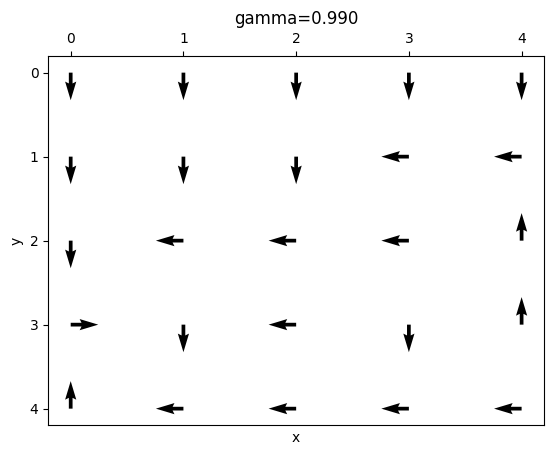

In [16]:
#################################################
### Learn and plot policy for given R and gamma
#################################################
# Run value iteration
gamma = 0.99
V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
print ("V=%s" % V)

# construct array with readable actions
print ("policy (numeric)=\n%s" % policy)
policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
print ("policy (readable)=\n%s" % policyReadable)

# Plot policy
plotPolicy (policy=policy, gamma=gamma)

Ending at iteration #2
Cum. error = 0.000000
V=[[  0.   0.   0.   0.   0.]
 [  0.   0.   0.   4.   6.]
 [  9.  11.  15.  17.  16.]
 [ 19.  20.  19.  23.  23.]
 [ 14.  16.   9.  10. -15.]]
policy (numeric)=
[[1 1 1 1 2]
 [0 0 0 2 2]
 [2 2 1 2 2]
 [2 2 2 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['UP' 'UP' 'UP' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
Ending at iteration #8
Cum. error = 0.000001
V=[[  0.11057      0.1316986    0.16938586   0.59385859   0.78158586]
 [  1.1056986    1.31698586   1.69385859   5.93858586   7.81585859]
 [ 11.05698586  13.16985859  16.93858586  19.38585859  18.15858586]
 [ 20.56985859  21.69858586  19.98585859  23.85858586  21.58585859]
 [ 15.69858586  16.98585859   9.85858586   8.58585859 -14.14141414]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 2]
 [2 2 1 2 2]
 [2 2 2 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' '

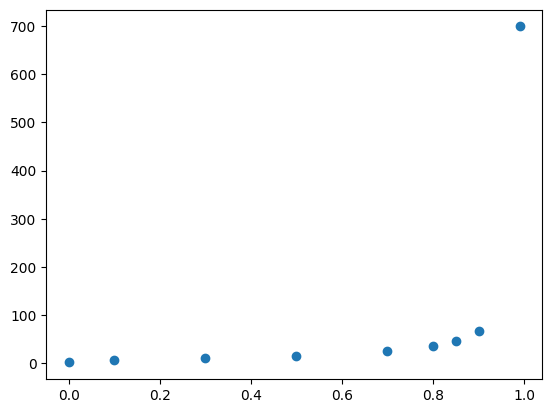

[0.0, 15.631717171999997, 75.08373636591311, 180.83333730697632, 323.25453330347716, 377.28721109836704, 425.8212829468074, 771.8115808030506, 11124.614569173646]


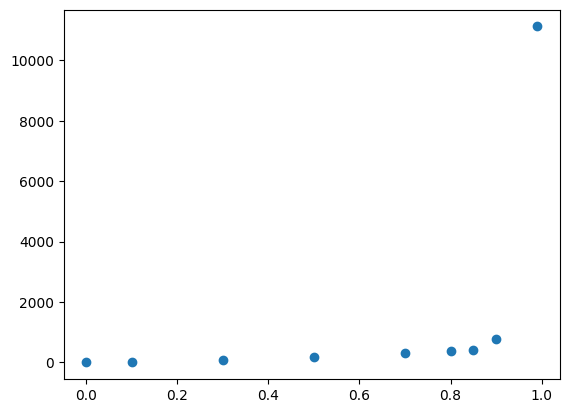

In [ ]:
gammas = [.0,.1,.3,.5,.7,.8,.85,.9,.99]
iterations = []
rewards_20 = []

def try_gammas():
    for gamma in gammas:
        V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
        print ("V=%s" % V)
        
        iterations.append(iteration)

        # construct array with readable actions
        print ("policy (numeric)=\n%s" % policy)
        policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
        print ("policy (readable)=\n%s" % policyReadable)

        # Plot policy
        #plotPolicy (policy=policy, gamma=gamma)
        
        reward_20 = 0
        s_init = (0,4)
        y,x = s_init
        cols, rows = policy.shape
        for i in range(20):
            reward_20 += V[y][x]
            action = policy[y][x]
            if action == RIGHT and x + 1 < cols:
                x += 1
            if action == LEFT and x != 0:
                x -= 1
            if action == UP and y + 1 < rows:
                y += 1
            if action == RIGHT and y != 0:
                y -= 1
        rewards_20.append(reward_20)
        
try_gammas()


# 3.1
plt.scatter(gammas, iterations) #plt.plot(gammas, iterations)
plt.show()

# 3.2
print(rewards_20)
plt.scatter(gammas, rewards_20) 
plt.show()

# 3.3
# gamma = .9 ist optimal


V=(579.043256097034, 573.2528235360637, 567.5202073432064, 561.8450052697743, 556.226455736251, 584.8922783614743, 579.043256097034, 573.2528235360637, 567.5202073432064, 561.8450052697743, 590.8002811732064, 584.8922783614743, 579.043256097034, 563.2528235360637, 552.226455736251, 587.6771405360638, 576.4415560970341, 558.6771405360638, 539.7968811732062, 530.7041911788884, 573.8002811732064, 562.0622783614743, 542.4415560970341, 522.0171405360637, 501.7968811732062)
error=0
iteration=1159
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]







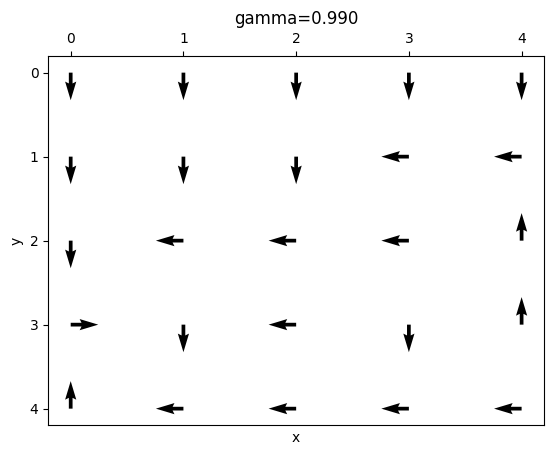

In [65]:
import mdptoolbox.mdp

gamma = 0.99
STATES = COLS * ROWS

# up action basically means going 5 states to left on linear representation of state grid 
# if we land in non existant state (s1-COLS < 0) we stay in current state (up in first row does nothing) 
up = np.array([[int(s1 - COLS == s2 or s1 - COLS < 0 and s1 == s2) for s2 in range(STATES)] for s1 in range(STATES)])
down = np.array([[int(s1 + COLS == s2 or s1 + COLS >= STATES and s1 == s2) for s2 in range(STATES)] for s1 in range(STATES)])
# if state left to s1 is in col > col of s1 we stay in s1 else move to left
left = np.array([[int(s1 == s2 if (s1 - 1) % COLS > (s1 % COLS) else s1 - 1 == s2) for s2 in range(STATES)] for s1 in range(STATES)])
right = np.array([[int(s1 == s2 if (s1 + 1) % COLS < (s1 % COLS) else s1 + 1 == s2) for s2 in range(STATES)] for s1 in range(STATES)])
#print(up.reshape(COLS, ROWS,COLS, ROWS))

transitions = np.array((up, right, down, left))

# https://pymdptoolbox.readthedocs.io/en/latest/api/mdp.html#mdptoolbox.mdp.MDP
# P needs shape (A, S, S), R shape (S, A)
vi = mdptoolbox.mdp.ValueIteration(transitions, RewardModel.reshape(STATES, len(ACTIONS)), gamma)
vi.run()
V, policy, iteration, error = vi.V, vi.policy, vi.iter, 0

print(f"{V=}")
print(f"{error=}")
print(f"{iteration=}")
policy = np.array(policy).reshape(COLS, ROWS)
print ("policy (numeric)=\n%s" % policy)

# construct array with readable actions
policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
print ("policy (readable)=\n%s" % policyReadable)

# Plot policy
plotPolicy (policy=policy, gamma=gamma)

ValueError: math domain error